 pumpkin data

In [13]:
import pandas as pd

# Read the US pumkin CSV file
pumpkins = pd.read_csv('../data/US-pumpkins.csv')

# Filter out any rows that donot use price per bushel
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel',case=True,regex=True)]
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [14]:
# Count how many cells in each columns are empty
pumpkins.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [15]:
#  Define the columns we want to keep
new_columns =['Package','Month', 'Low Price', 'High Price', 'Date']

# Drop all other columns
pumpkins = pumpkins.drop([c for c in pumpkins.columns if c not in new_columns],axis=1)

In [16]:
#  Calculate the average from the high low price
price = (pumpkins['Low Price'] + pumpkins['High Price'])/2

#  Get the month from the date column
month= pd.DatetimeIndex(pumpkins['Date']).month

# Create a new data frame with these columns
new_pumpkins = pd.DataFrame({"Month":month, "Package":pumpkins['Package'],'Low Price':pumpkins['Low Price'],'High Price':pumpkins['High Price']})


In [17]:
# Convert the price of all cells prices by 1 1/9 bushels by dividing 1 1/9
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'),'Price'] = price/(1+ 1/9)

#  conver the price of all cells prices by 1/2 bushels by diving by 1/2
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'),'price'] = price/(1/2)


In [18]:
#  Print the first few ow from the data frame
new_pumpkins.head()

,Month,Package,Low Price,High Price,Price,price
70,9,1 1/9 bushel cartons,15.0,15.0,13.5,NaN
71,9,1 1/9 bushel cartons,18.0,18.0,16.2,NaN
72,10,1 1/9 bushel cartons,18.0,18.0,16.2,NaN
73,10,1 1/9 bushel cartons,17.0,17.0,15.3,NaN
74,10,1 1/9 bushel cartons,15.0,15.0,13.5,NaN


<function matplotlib.pyplot.show(close=None, block=None)>

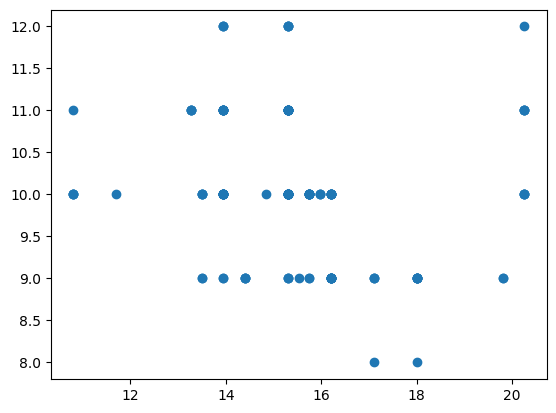

In [20]:
import matplotlib.pyplot as plt
#  Get the calies we want to plot
price = new_pumpkins.Price
month = new_pumpkins.Month

#  Create a show scatter plot of price vs month
plt.scatter(price, month)
plt.show

Text(0, 0.5, 'Pumkins Price')

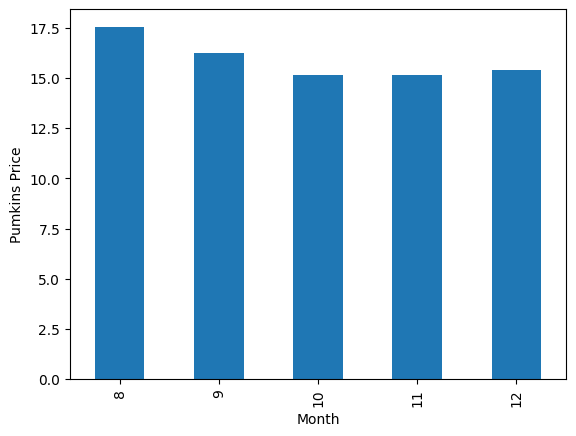

In [21]:
#  Group the pumkins into a bar chart by month and price
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')

# Add a label to the bar chart
plt.ylabel("Pumkins Price")